<a href="https://colab.research.google.com/github/kavinkumarManielayaperumal/Toy-Model-for-Gaussian-Mixture-in-Traffic-Scenario-Group-Project./blob/main_toy/GMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Necessary libraries***

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive

# ***Model***

Initialization

Define E-step (Expectation)

Define M-step (Maximization)

Combine into EM Algorithm
Assign Clusters and Visualize

# ***Mount the drive***

In [2]:
# Load Standardized File (Before Initialization) for the single file
# Load the standardized file
drive.mount('/content/drive')
file_path =r"/content/drive/My Drive/for data/for the y axis flipping /cleaned_file.csv"
data = pd.read_csv(file_path)
# Convert to NumPy array (optional, if not working with pandas)
X = data.values  # X is the standardized data (n_samples, n_features)

Mounted at /content/drive


# ***Initialization***

In [3]:
def initialize_parameters(X, num_clusters, precomputed_means=None, precomputed_covariances=None):
    """
    Initializes the parameters for GMM.

    Parameters:
    X (numpy.ndarray): The dataset of shape (n_samples, n_features).
    num_clusters (int): The number of clusters (Gaussian components).
    precomputed_means (list of numpy.ndarray, optional): Precomputed means for each cluster.
    precomputed_covariances (list of numpy.ndarray, optional): Precomputed covariance matrices for each cluster.

    Returns:
    means (numpy.ndarray): Initial means for each cluster of shape (num_clusters, n_features).
    covariances (list of numpy.ndarray): Initial covariance matrices for each cluster.
    weights (numpy.ndarray): Initial weights for each cluster of shape (num_clusters,).
    """
    np.random.seed(42)  # For reproducibility
    n_samples, n_features = X.shape

    if precomputed_means is not None and precomputed_covariances is not None:
        # Use precomputed means and covariances
        initial_means = np.array(precomputed_means)
        initial_covariances = [np.array(cov) for cov in precomputed_covariances]
    else:
        # Random initialization
        initial_means = X[np.random.choice(n_samples, num_clusters, replace=False)]
        initial_covariances = [np.eye(n_features) for _ in range(num_clusters)]

    # Initialize weights equally
    initial_weights = np.ones(num_clusters) / num_clusters

    return initial_means, initial_covariances, initial_weights


In [4]:
# Precomputed means and covariances from your earlier results
precomputed_means = [
    [0.30528865, 0.28376041],  # Mean for Class 0
    [0.26783629, 0.30334404],  # Mean for Class -1
    [0.27020489, 0.30522999],  # Mean for Class 1
]

precomputed_covariances = [
    [[0.10695915, 0.00057061], [0.00057061, 0.05187869]],  # Covariance for Class 0
    [[0.10454952, -0.01795062], [-0.01795062, 0.0758242]],  # Covariance for Class -1
    [[0.1185913, 0.0026262], [0.0026262, 0.05105351]],  # Covariance for Class 1
]

# Assuming 'data_standardized' is your dataset and num_clusters = 3
means, covariances, weights = initialize_parameters(X, 3, precomputed_means, precomputed_covariances
)

# Print the initialized parameters
print("Initialized Means:\n", means)
print("Initialized Covariances:\n", covariances)
print("Initialized Weights:\n", weights)

Initialized Means:
 [[0.30528865 0.28376041]
 [0.26783629 0.30334404]
 [0.27020489 0.30522999]]
Initialized Covariances:
 [array([[0.10695915, 0.00057061],
       [0.00057061, 0.05187869]]), array([[ 0.10454952, -0.01795062],
       [-0.01795062,  0.0758242 ]]), array([[0.1185913 , 0.0026262 ],
       [0.0026262 , 0.05105351]])]
Initialized Weights:
 [0.33333333 0.33333333 0.33333333]


# ***Define E-step (Expectation)***

In [5]:
# E-step: Calculate posterior probabilities (responsibilities)
def e_step(X, means, covariances, weights, num_clusters):
    n_samples, n_features = X.shape
    responsibilities = np.zeros((n_samples, num_clusters))

    for k in range(num_clusters):
        diff = X - means[k]
        cov_inv = np.linalg.inv(covariances[k])
        exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariances[k]))
        responsibilities[:, k] = weights[k] * np.exp(exponent) / normalization

    # Normalize responsibilities
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return responsibilities

# ***Define M-step (Maximization)***

In [6]:
# M-step: Update parameters
def m_step(X, responsibilities, num_clusters):
    n_samples, n_features = X.shape
    weights = responsibilities.sum(axis=0) / n_samples
    means = np.zeros((num_clusters, n_features))
    covariances = []

    for k in range(num_clusters):
        resp = responsibilities[:, k]
        total_resp = resp.sum()

        # Update means
        means[k] = np.sum(resp[:, np.newaxis] * X, axis=0) / total_resp

        # Update covariances
        diff = X - means[k]
        cov = (resp[:, np.newaxis] * diff).T @ diff / total_resp
        covariances.append(cov)

    return means, covariances, weights

# ***Combine into EM Algorithm***

In [7]:
 # that need improvement to handle potential issues such as singular matrices, numerical instability, or divide-by-zero errors.

def run_em_algorithm(X, precomputed_means=None, precomputed_covariances=None, num_clusters=3, max_iter=100, tol=1e-6):
    means, covariances, weights = initialize_parameters(
        X, num_clusters, precomputed_means, precomputed_covariances
    )
    log_likelihood_old = 0

    means_list, covariances_list, weights_list, saved_iterations = [], [], [], []

    for iteration in range(max_iter):
        # E-step
        responsibilities = e_step(X, means, covariances, weights, num_clusters)

        # M-step
        means, covariances, weights = m_step(X, responsibilities, num_clusters)

        # Regularize covariances
        epsilon = 1e-6
        covariances = [cov + epsilon * np.eye(cov.shape[0]) for cov in covariances]

        # Save parameters
        if iteration % 10 == 0 or iteration == 0:
            means_list.append(means.copy())
            covariances_list.append([cov.copy() for cov in covariances])
            weights_list.append(weights.copy())
            saved_iterations.append(iteration)

        # Compute log-likelihood
        log_likelihood = np.sum(
            np.log(
                np.sum(
                    [
                        weights[k] * multivariate_gaussian(X, means[k], covariances[k])
                        for k in range(num_clusters)
                    ],
                    axis=0,
                ) + 1e-10
            )
        )
        print(f"Iteration {iteration}, Log-likelihood: {log_likelihood}")

        # Check convergence
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        log_likelihood_old = log_likelihood

    return means, covariances, weights, responsibilities, means_list, covariances_list, weights_list, saved_iterations


def multivariate_gaussian(X, mean, covariance):
    n_features = X.shape[1]
    epsilon = 1e-6
    covariance += epsilon * np.eye(covariance.shape[0])

    diff = X - mean
    cov_inv = np.linalg.inv(covariance)
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
    normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariance))
    return np.exp(exponent) / normalization

In [8]:
# Number of clusters for your project (e.g., Left, Straight, Right)
num_clusters = 3
max_iter = 100
tol = 1e-6

# Specify iterations for visualization
visualize_steps = [0, 30,60,90]

final_means, final_covariances, final_weights, final_responsibilities, means_list, covariances_list, weights_list, saved_iterations = run_em_algorithm(
    X, precomputed_means=precomputed_means, precomputed_covariances=precomputed_covariances, num_clusters=3, max_iter=100, tol=1e-6
)
# Print final parameters for verification
print("\nFinal Means:\n", final_means)
print("\nFinal Covariances:\n", final_covariances)
print("\nFinal Weights:\n", final_weights)


Iteration 0, Log-likelihood: -2896217.019334761
Iteration 1, Log-likelihood: -2583395.4459470445
Iteration 2, Log-likelihood: -2234548.09369502
Iteration 3, Log-likelihood: -1947827.740661279
Iteration 4, Log-likelihood: -1698793.4098471098
Iteration 5, Log-likelihood: -1467582.7530464537
Iteration 6, Log-likelihood: -1261060.4699743788
Iteration 7, Log-likelihood: -1093986.2126681576
Iteration 8, Log-likelihood: -974738.7950374589
Iteration 9, Log-likelihood: -898488.2707585797
Iteration 10, Log-likelihood: -851603.854850912
Iteration 11, Log-likelihood: -820448.8395831068
Iteration 12, Log-likelihood: -795685.9782118958
Iteration 13, Log-likelihood: -772028.8353738354
Iteration 14, Log-likelihood: -746776.5926114761
Iteration 15, Log-likelihood: -718756.193337178
Iteration 16, Log-likelihood: -687786.5711751815
Iteration 17, Log-likelihood: -654365.9288132801
Iteration 18, Log-likelihood: -619368.1553975472
Iteration 19, Log-likelihood: -583730.0069449241
Iteration 20, Log-likelihood

# ***Assign Clusters and Visualize***

In [9]:
print(f"Length of means_list: {len(means_list)}")
print(f"Length of covariances_list: {len(covariances_list)}")
print(f"Length of weights_list: {len(weights_list)}")
print(f"Visualize steps: {saved_iterations}")

Length of means_list: 10
Length of covariances_list: 10
Length of weights_list: 10
Visualize steps: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def visualize_gmm_progression(X, means_list, covariances_list, weights_list,saved_iterations, feature_idx1=0, feature_idx2=1):
    """
    Visualizes GMM clustering progression for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        visualize_steps (list): Iterations for which to visualize the clustering.
        feature_idx1 (int): Index of the first feature to plot (default: 0).
        feature_idx2 (int): Index of the second feature to plot (default: 1).
    """
    x_range = np.linspace(np.min(X[:, feature_idx1]), np.max(X[:, feature_idx1]), 500)
    y_range = np.linspace(np.min(X[:, feature_idx2]), np.max(X[:, feature_idx2]), 500)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the data points
        plt.scatter(X[:, feature_idx1], X[:, feature_idx2], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions
        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            covariance = covariances_list[step_idx][cluster_idx]

            # Extract 2D subspace of the covariance matrix
            sub_covariance = covariance[np.ix_([feature_idx1, feature_idx2], [feature_idx1, feature_idx2])]
            sub_mean = mean[[feature_idx1, feature_idx2]]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(sub_mean, sub_covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration}")
        plt.xlabel(f"Feature {feature_idx1 + 1}")
        plt.ylabel(f"Feature {feature_idx2 + 1}")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)


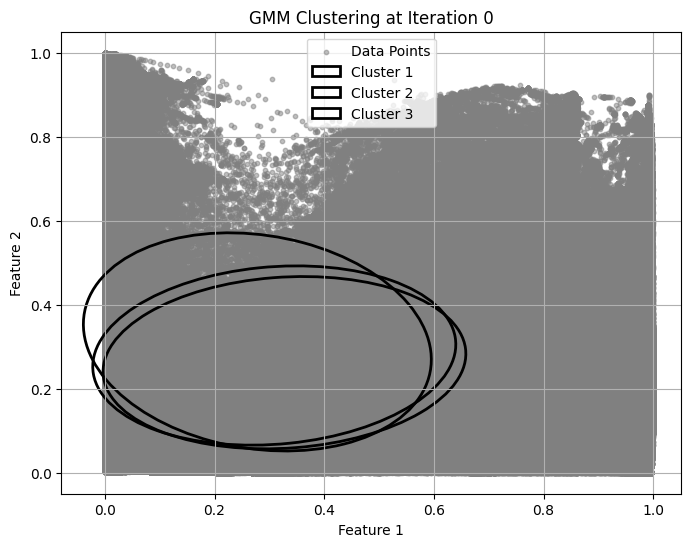

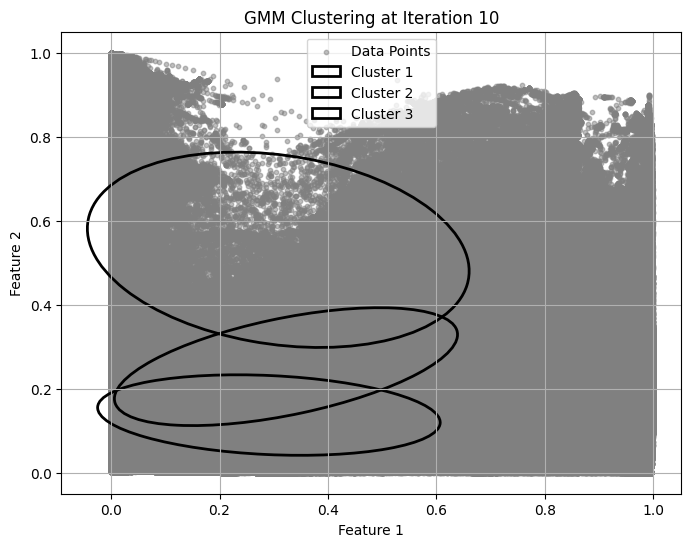

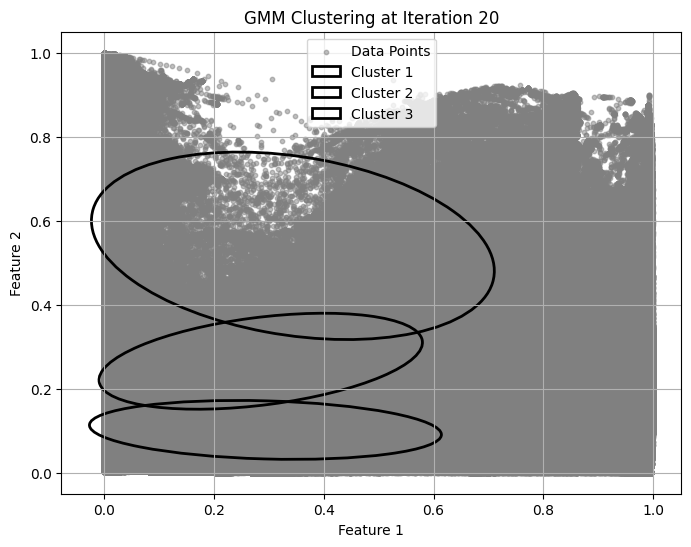

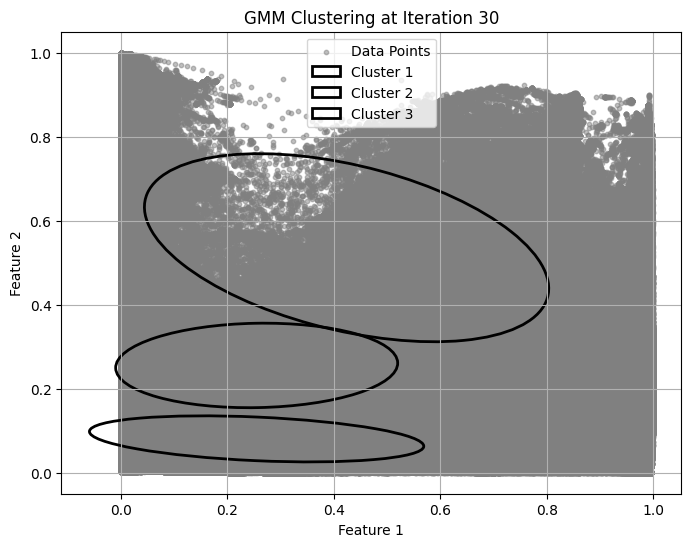

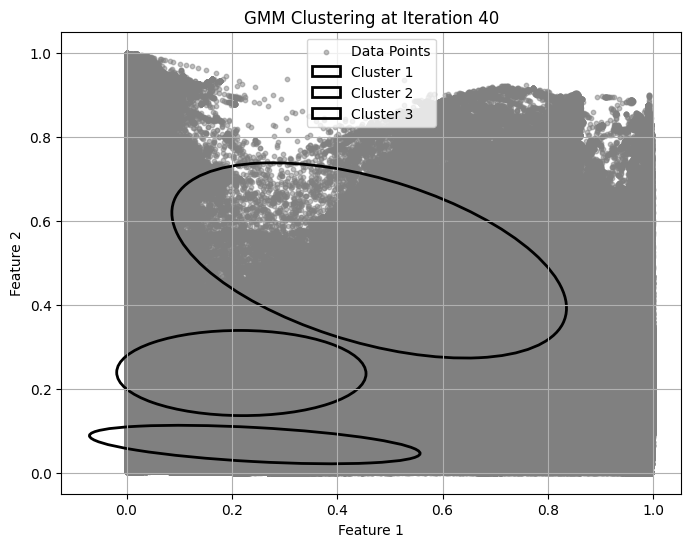

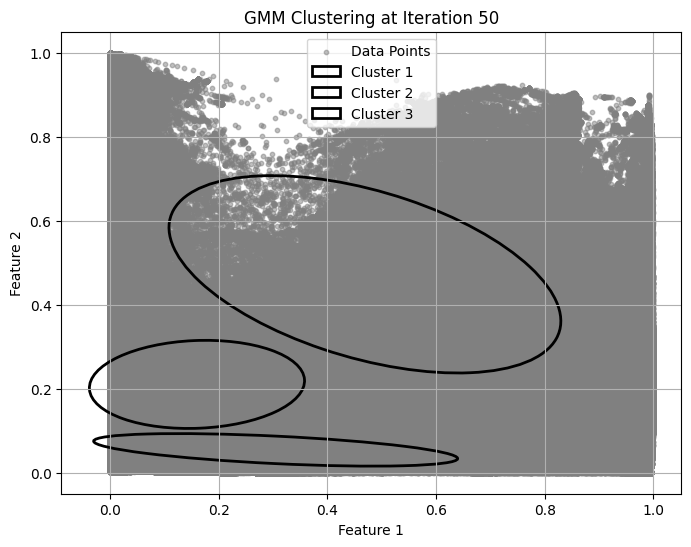

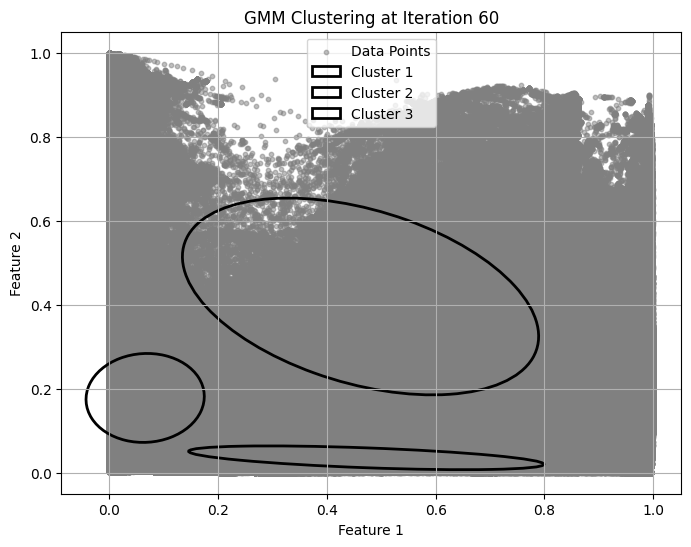

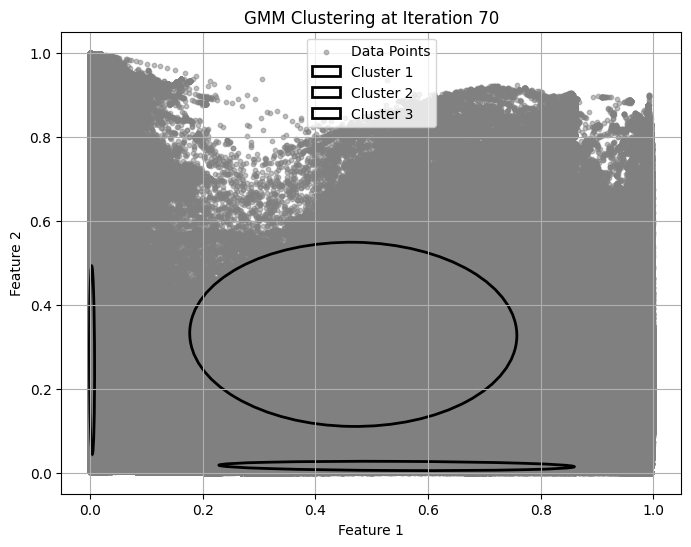

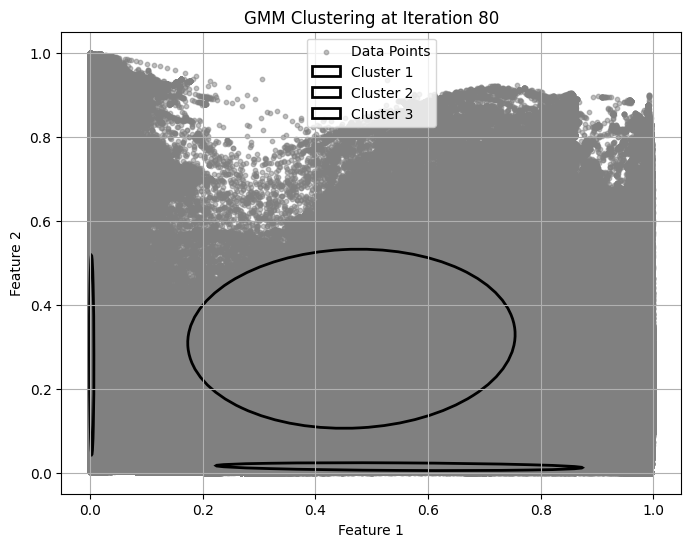

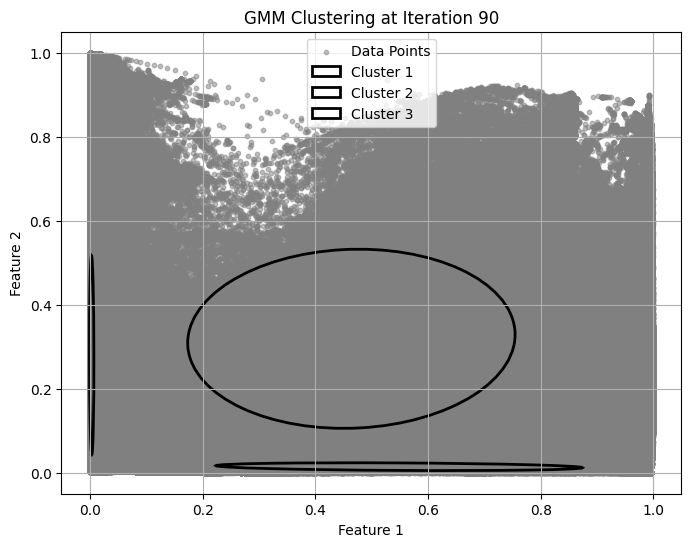

In [11]:
# Call the visualization function
visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=0, feature_idx2=1)

# ***visualization in 1D***

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_combined_feature_bell_curve(X, means_list, covariances_list, saved_iterations):
    """
    Combines multiple features into one and visualizes Gaussian bell-shaped curves for the combined feature.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.

    Returns:
        None
    """
    # Step 1: Combine features into a single feature (e.g., sum of all features)
    combined_feature = X.sum(axis=1)  # You can replace this with another aggregation method

    # Step 2: Plot Gaussian bell-shaped curves iteratively
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(10, 6))

        # Generate a range of values for the combined feature
        x_range = np.linspace(combined_feature.min()-1, combined_feature.max()+1, 500)

        # Plot Gaussian bell-shaped curves for each cluster
        for cluster_idx in range(len(means_list[step_idx])):
            # Compute the mean and variance for the combined feature
            mean_combined = means_list[step_idx][cluster_idx].sum()
            variance_combined = np.diag(covariances_list[step_idx][cluster_idx]).sum()

            # Compute Gaussian PDF
            gaussian_pdf = norm.pdf(x_range, loc=mean_combined, scale=np.sqrt(variance_combined))
            plt.plot(x_range, gaussian_pdf, label=f"Cluster {cluster_idx + 1}", lw=2)

        # Add title and labels
        plt.title(f"Gaussian Bell-Shaped Curve for Combined Feature at Iteration {iteration}")
        plt.xlabel("Combined Feature")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid()
        plt.show()

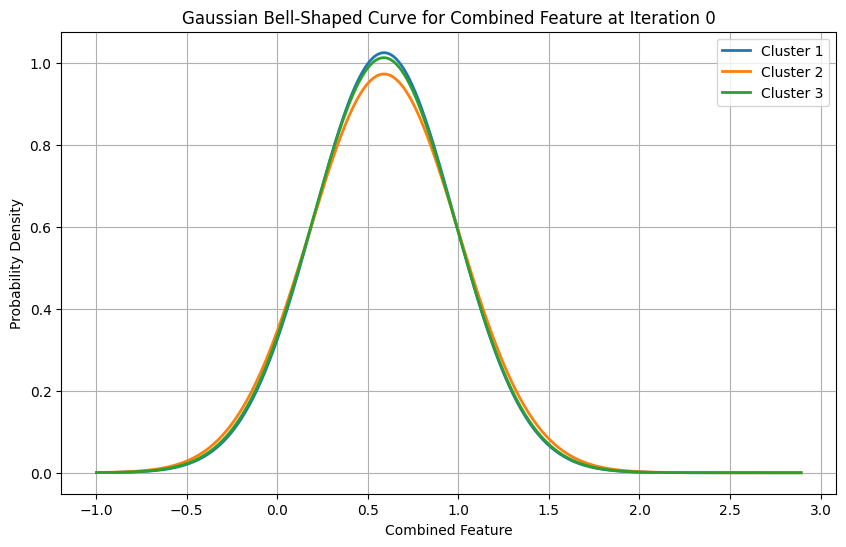

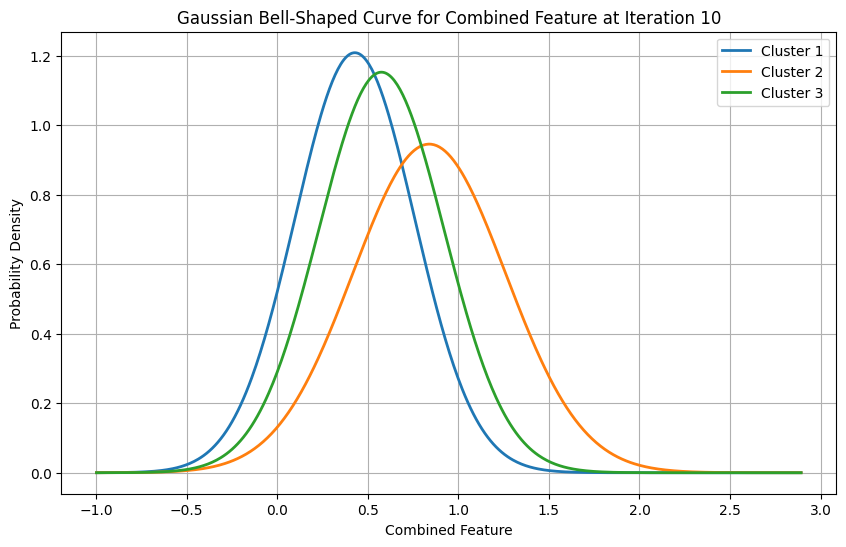

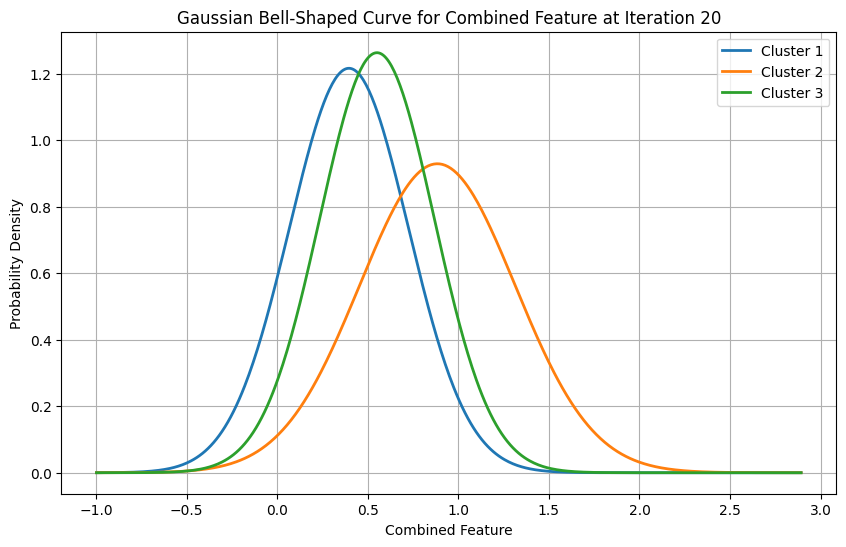

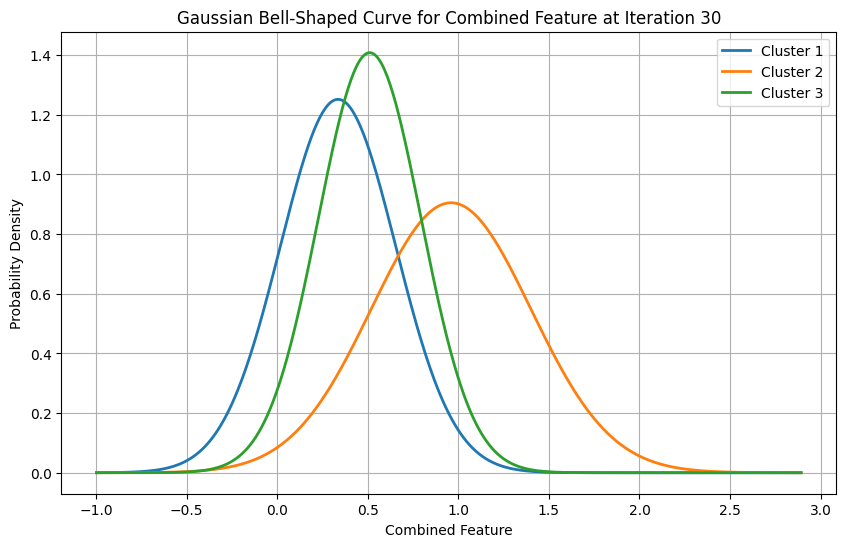

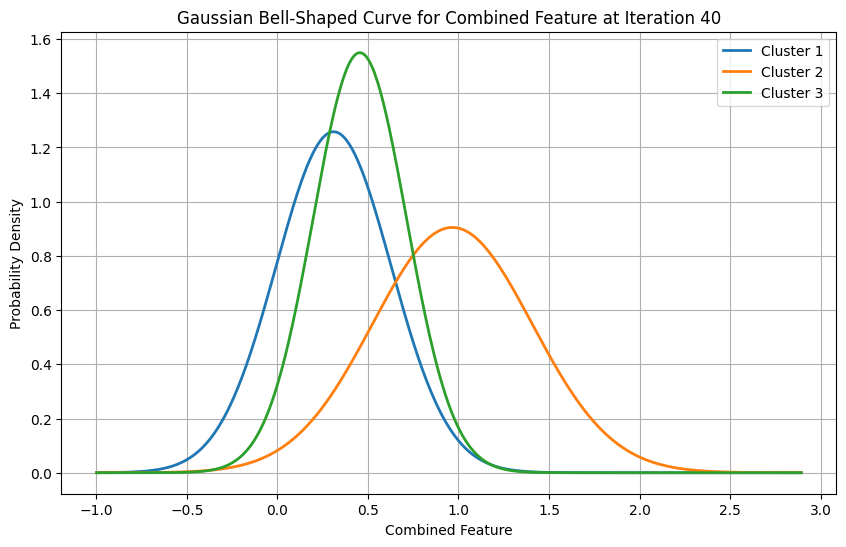

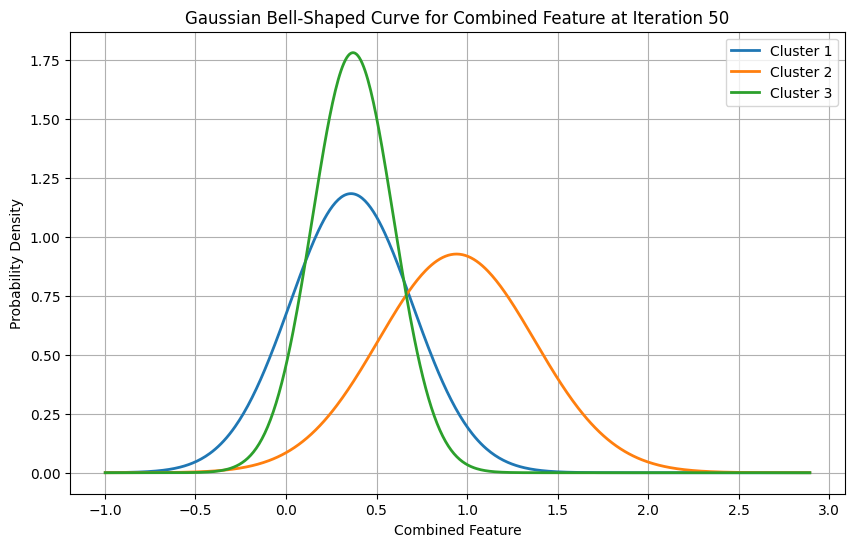

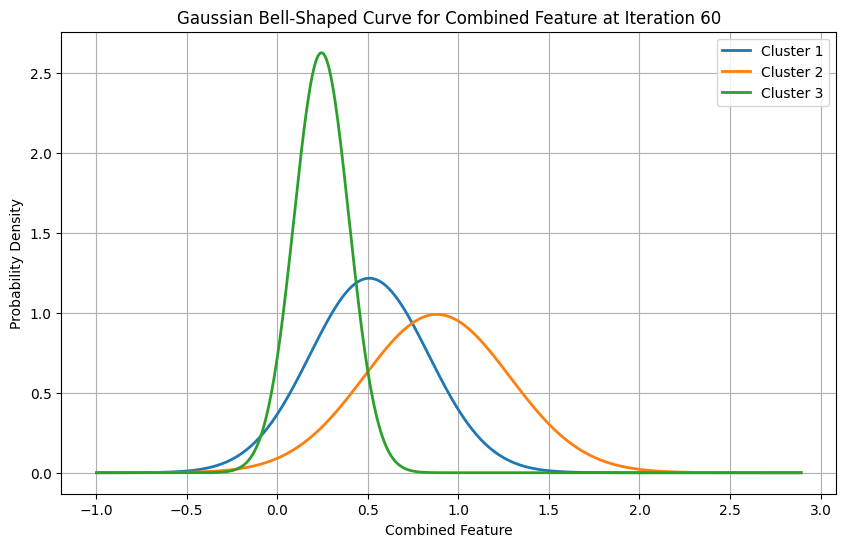

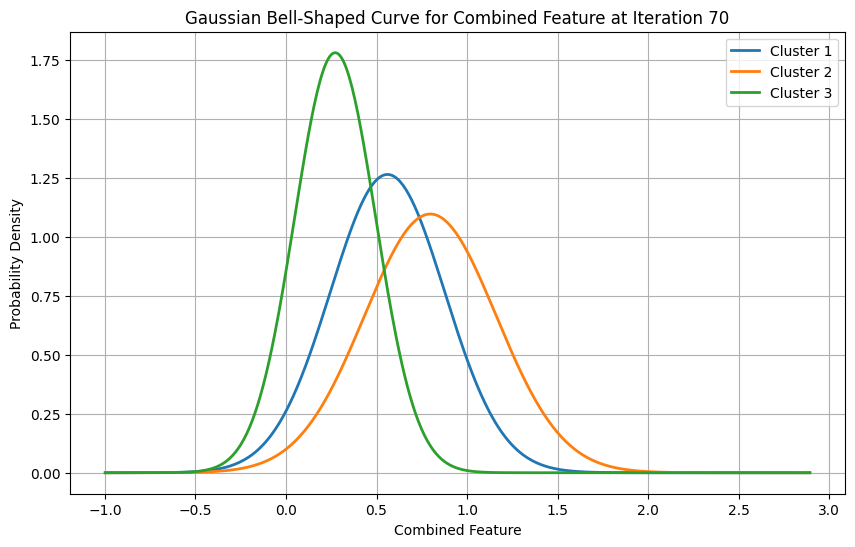

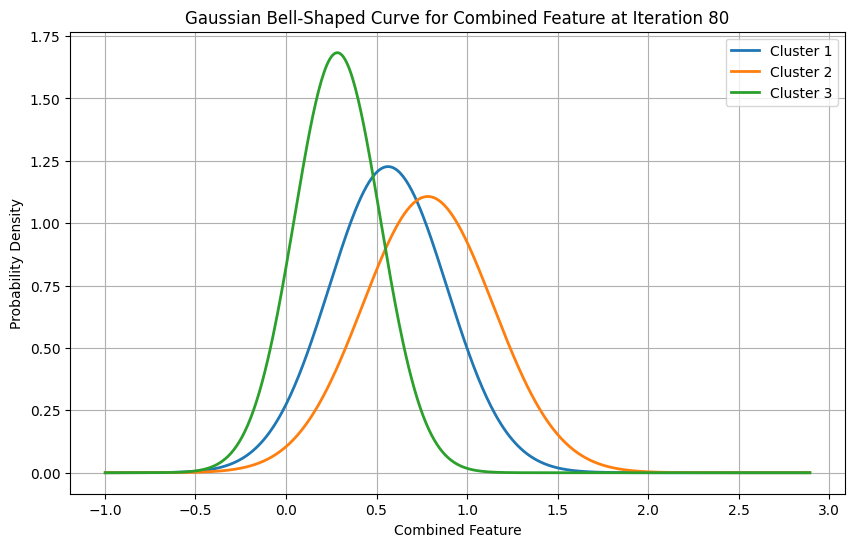

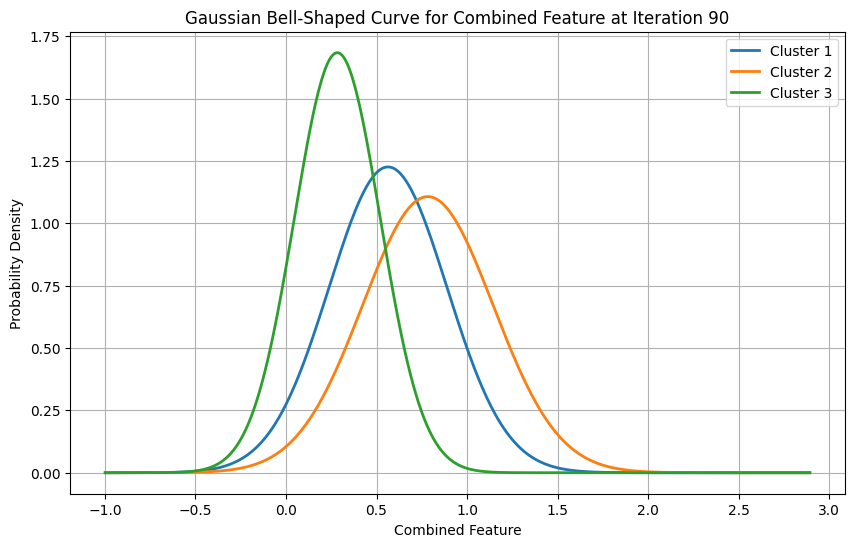

In [19]:
# Call the function
visualize_combined_feature_bell_curve(
    X,                # Standardized dataset
    means_list,       # List of means for each iteration
    covariances_list, # List of covariance matrices for each iteration
    saved_iterations  # Iterations to visualize
)


# ***For the subcluster***

In [ ]:
# Load Standardized File (Before Initialization) for the single file
# Load the standardized file
drive.mount('/content/drive')
file_path =r"/content/drive/My Drive/for data/for the y axis flipping /cleaned_file.csv"
data = pd.read_csv(file_path)
# Convert to NumPy array (optional, if not working with pandas)
X = data.values  # X is the standardized data (n_samples, n_features)

# ***Initialization***

In [ ]:
import numpy as np

# Function to initialize the parameters
def initialize_parameters(X, num_clusters):
    """
    Initializes the parameters for GMM.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).

    Returns:
        means (numpy.ndarray): Initial means for each cluster of shape (num_clusters, n_features).
        covariances (list of numpy.ndarray): Initial covariance matrices for each cluster.
        weights (numpy.ndarray): Initial weights for each cluster of shape (num_clusters,).
    """
    np.random.seed(42)  # For reproducibility
    n_samples, n_features = X.shape

    # Step 1: Initialize means by randomly sampling data points
    initial_means = X[np.random.choice(n_samples, num_clusters, replace=False)]

    # Step 2: Initialize covariances as identity matrices
    initial_covariances = [np.eye(n_features)for _ in range(num_clusters)]

    # Step 3: Initialize weights equally
    initial_weights = np.ones(num_clusters) / num_clusters

    return initial_means, initial_covariances, initial_weights

# Example usage:
# Assuming `data_standardized` is your standardized dataset
num_clusters = 3  # Number of clusters (e.g., Left, Straight, Right)
means, covariances, weights = initialize_parameters(X, num_clusters)

# Print the initialized parameters
print("Initial Means:\n", means)
print("\nInitial Covariances:\n", covariances)
print("\nInitial Weights:\n", weights)


# ***Define E-step (Expectation)***

In [ ]:
# E-step: Calculate posterior probabilities (responsibilities)
def e_step(X, means, covariances, weights, num_clusters):
    n_samples, n_features = X.shape
    responsibilities = np.zeros((n_samples, num_clusters))

    for k in range(num_clusters):
        diff = X - means[k]
        cov_inv = np.linalg.inv(covariances[k])
        exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariances[k]))
        responsibilities[:, k] = weights[k] * np.exp(exponent) / normalization

    # Normalize responsibilities
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return responsibilities

# ***Combine into EM Algorithm***

In [ ]:
def run_em_algorithm(X, num_clusters, max_iter=100, tol=1e-6):
    means, covariances, weights = initialize_parameters(X, num_clusters)
    log_likelihood_old = 0

    means_list, covariances_list, weights_list, saved_iterations = [], [], [], []

    for iteration in range(max_iter):
        # E-step
        responsibilities = e_step(X, means, covariances, weights, num_clusters)

        # M-step
        means, covariances, weights = m_step(X, responsibilities, num_clusters)

        # Regularize covariances
        epsilon = 1e-6
        covariances = [cov + epsilon * np.eye(cov.shape[0]) for cov in covariances]

        # Save parameters
        if iteration % 10 == 0 or iteration == 0:
            means_list.append(means.copy())
            covariances_list.append([cov.copy() for cov in covariances])
            weights_list.append(weights.copy())
            saved_iterations.append(iteration)

        # Compute log-likelihood
        log_likelihood = np.sum(
            np.log(
                np.sum(
                    [
                        weights[k] * multivariate_gaussian(X, means[k], covariances[k])
                        for k in range(num_clusters)
                    ],
                    axis=0,
                ) + 1e-10
            )
        )
        print(f"Iteration {iteration}, Log-likelihood: {log_likelihood}")

        # Check convergence
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        log_likelihood_old = log_likelihood

    return means, covariances, weights, responsibilities, means_list, covariances_list, weights_list, saved_iterations


def multivariate_gaussian(X, mean, covariance):
    n_features = X.shape[1]
    epsilon = 1e-6
    covariance += epsilon * np.eye(covariance.shape[0])

    diff = X - mean
    cov_inv = np.linalg.inv(covariance)
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
    normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariance))
    return np.exp(exponent) / normalization

In [ ]:
# Number of clusters for your project (e.g., Left, Straight, Right)
num_clusters = 3
max_iter = 100
tol = 1e-6

# Specify iterations for visualization
visualize_steps = [0, 30,60,90]

# Run the EM algorithm with visualization steps
final_means, final_covariances, final_weights, final_responsibilities, means_list, covariances_list, weights_list,saved_iterations = run_em_algorithm(
    X, num_clusters=3, max_iter=100, tol=1e-6)


# Print final parameters for verification
print("\nFinal Means:\n", final_means)
print("\nFinal Covariances:\n", final_covariances)
print("\nFinal Weights:\n", final_weights)

# ***Assign Clusters and Visualize***

In [ ]:
print(f"Length of means_list: {len(means_list)}")
print(f"Length of covariances_list: {len(covariances_list)}")
print(f"Length of weights_list: {len(weights_list)}")
print(f"Visualize steps: {saved_iterations}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def visualize_gmm_progression(X, means_list, covariances_list, weights_list,saved_iterations, feature_idx1=0, feature_idx2=1):
    """
    Visualizes GMM clustering progression for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        visualize_steps (list): Iterations for which to visualize the clustering.
        feature_idx1 (int): Index of the first feature to plot (default: 0).
        feature_idx2 (int): Index of the second feature to plot (default: 1).
    """
    x_range = np.linspace(np.min(X[:, feature_idx1]), np.max(X[:, feature_idx1]), 500)
    y_range = np.linspace(np.min(X[:, feature_idx2]), np.max(X[:, feature_idx2]), 500)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the data points
        plt.scatter(X[:, feature_idx1], X[:, feature_idx2], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions
        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            covariance = covariances_list[step_idx][cluster_idx]

            # Extract 2D subspace of the covariance matrix
            sub_covariance = covariance[np.ix_([feature_idx1, feature_idx2], [feature_idx1, feature_idx2])]
            sub_mean = mean[[feature_idx1, feature_idx2]]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(sub_mean, sub_covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration}")
        plt.xlabel(f"Feature {feature_idx1 + 1}")
        plt.ylabel(f"Feature {feature_idx2 + 1}")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)


In [ ]:
# Call the visualization function
visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=0, feature_idx2=1)

# ***visualzation 1D***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_combined_feature_bell_curve(X, means_list, covariances_list, saved_iterations):
    """
    Combines multiple features into one and visualizes Gaussian bell-shaped curves for the combined feature.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.

    Returns:
        None
    """
    # Step 1: Combine features into a single feature (e.g., sum of all features)
    combined_feature = X.sum(axis=1)  # You can replace this with another aggregation method

    # Step 2: Plot Gaussian bell-shaped curves iteratively
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(10, 6))

        # Generate a range of values for the combined feature
        x_range = np.linspace(combined_feature.min(), combined_feature.max(), 500)

        # Plot Gaussian bell-shaped curves for each cluster
        for cluster_idx in range(len(means_list[step_idx])):
            # Compute the mean and variance for the combined feature
            mean_combined = means_list[step_idx][cluster_idx].sum()
            variance_combined = np.diag(covariances_list[step_idx][cluster_idx]).sum()

            # Compute Gaussian PDF
            gaussian_pdf = norm.pdf(x_range, loc=mean_combined, scale=np.sqrt(variance_combined))
            plt.plot(x_range, gaussian_pdf, label=f"Cluster {cluster_idx + 1}", lw=2)

        # Add title and labels
        plt.title(f"Gaussian Bell-Shaped Curve for Combined Feature at Iteration {iteration}")
        plt.xlabel("Combined Feature")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid()
        plt.show()

In [ ]:


# Call the function
visualize_combined_feature_bell_curve(
    X,                # Standardized dataset
    means_list,       # List of means for each iteration
    covariances_list, # List of covariance matrices for each iteration
    saved_iterations  # Iterations to visualize
)


# ***sub cluster 2***

In [ ]:
# Load Standardized File (Before Initialization) for the single file
# Load the standardized file
drive.mount('/content/drive')
file_path =r"/content/drive/My Drive/for data/for the y axis flipping /cleaned_file.csv"
data = pd.read_csv(file_path)
# Convert to NumPy array (optional, if not working with pandas)
X = data.values  # X is the standardized data (n_samples, n_features)

# ***Initialization***

In [ ]:
import numpy as np

# Function to initialize the parameters
def initialize_parameters(X, num_clusters):
    """
    Initializes the parameters for GMM.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).

    Returns:
        means (numpy.ndarray): Initial means for each cluster of shape (num_clusters, n_features).
        covariances (list of numpy.ndarray): Initial covariance matrices for each cluster.
        weights (numpy.ndarray): Initial weights for each cluster of shape (num_clusters,).
    """
    np.random.seed(42)  # For reproducibility
    n_samples, n_features = X.shape

    # Step 1: Initialize means by randomly sampling data points
    initial_means = X[np.random.choice(n_samples, num_clusters, replace=False)]

    # Step 2: Initialize covariances as identity matrices
    initial_covariances = [np.eye(n_features)for _ in range(num_clusters)]

    # Step 3: Initialize weights equally
    initial_weights = np.ones(num_clusters) / num_clusters

    return initial_means, initial_covariances, initial_weights

# Example usage:
# Assuming `data_standardized` is your standardized dataset
num_clusters = 3  # Number of clusters (e.g., Left, Straight, Right)
means, covariances, weights = initialize_parameters(X, num_clusters)

# Print the initialized parameters
print("Initial Means:\n", means)
print("\nInitial Covariances:\n", covariances)
print("\nInitial Weights:\n", weights)

# ***Define E-step (Expectation)***

In [ ]:
# E-step: Calculate posterior probabilities (responsibilities)
def e_step(X, means, covariances, weights, num_clusters):
    n_samples, n_features = X.shape
    responsibilities = np.zeros((n_samples, num_clusters))

    for k in range(num_clusters):
        diff = X - means[k]
        cov_inv = np.linalg.inv(covariances[k])
        exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariances[k]))
        responsibilities[:, k] = weights[k] * np.exp(exponent) / normalization

    # Normalize responsibilities
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return responsibilities

# ***Define M-step (Maximization)***

In [ ]:
# M-step: Update parameters
def m_step(X, responsibilities, num_clusters):
    n_samples, n_features = X.shape
    weights = responsibilities.sum(axis=0) / n_samples
    means = np.zeros((num_clusters, n_features))
    covariances = []

    for k in range(num_clusters):
        resp = responsibilities[:, k]
        total_resp = resp.sum()

        # Update means
        means[k] = np.sum(resp[:, np.newaxis] * X, axis=0) / total_resp

        # Update covariances
        diff = X - means[k]
        cov = (resp[:, np.newaxis] * diff).T @ diff / total_resp
        covariances.append(cov)

    return means, covariances, weights

# ***Combine into EM Algorithm***

In [ ]:
# that need improvement to handle potential issues such as singular matrices, numerical instability, or divide-by-zero errors.

def run_em_algorithm(X, num_clusters, max_iter=100, tol=1e-6):
    means, covariances, weights = initialize_parameters(X, num_clusters)
    log_likelihood_old = 0

    means_list, covariances_list, weights_list, saved_iterations = [], [], [], []

    for iteration in range(max_iter):
        # E-step
        responsibilities = e_step(X, means, covariances, weights, num_clusters)

        # M-step
        means, covariances, weights = m_step(X, responsibilities, num_clusters)

        # Regularize covariances
        epsilon = 1e-6
        covariances = [cov + epsilon * np.eye(cov.shape[0]) for cov in covariances]

        # Save parameters
        if iteration % 10 == 0 or iteration == 0:
            means_list.append(means.copy())
            covariances_list.append([cov.copy() for cov in covariances])
            weights_list.append(weights.copy())
            saved_iterations.append(iteration)

        # Compute log-likelihood
        log_likelihood = np.sum(
            np.log(
                np.sum(
                    [
                        weights[k] * multivariate_gaussian(X, means[k], covariances[k])
                        for k in range(num_clusters)
                    ],
                    axis=0,
                ) + 1e-10
            )
        )
        print(f"Iteration {iteration}, Log-likelihood: {log_likelihood}")

        # Check convergence
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        log_likelihood_old = log_likelihood

    return means, covariances, weights, responsibilities, means_list, covariances_list, weights_list, saved_iterations


def multivariate_gaussian(X, mean, covariance):
    n_features = X.shape[1]
    epsilon = 1e-6
    covariance += epsilon * np.eye(covariance.shape[0])

    diff = X - mean
    cov_inv = np.linalg.inv(covariance)
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
    normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariance))
    return np.exp(exponent) / normalization


In [ ]:
# Number of clusters for your project (e.g., Left, Straight, Right)
num_clusters = 3
max_iter = 100
tol = 1e-6

# Specify iterations for visualization
visualize_steps = [0, 30,60,90]

# Run the EM algorithm with visualization steps
final_means, final_covariances, final_weights, final_responsibilities, means_list, covariances_list, weights_list,saved_iterations = run_em_algorithm(
    X, num_clusters=3, max_iter=100, tol=1e-6)


# Print final parameters for verification
print("\nFinal Means:\n", final_means)
print("\nFinal Covariances:\n", final_covariances)
print("\nFinal Weights:\n", final_weights)

# ***Assign Clusters and Visualize***

In [ ]:
print(f"Length of means_list: {len(means_list)}")
print(f"Length of covariances_list: {len(covariances_list)}")
print(f"Length of weights_list: {len(weights_list)}")
print(f"Visualize steps: {saved_iterations}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def visualize_gmm_progression(X, means_list, covariances_list, weights_list,saved_iterations, feature_idx1=0, feature_idx2=1):
    """
    Visualizes GMM clustering progression for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        visualize_steps (list): Iterations for which to visualize the clustering.
        feature_idx1 (int): Index of the first feature to plot (default: 0).
        feature_idx2 (int): Index of the second feature to plot (default: 1).
    """
    x_range = np.linspace(np.min(X[:, feature_idx1]), np.max(X[:, feature_idx1]), 500)
    y_range = np.linspace(np.min(X[:, feature_idx2]), np.max(X[:, feature_idx2]), 500)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the data points
        plt.scatter(X[:, feature_idx1], X[:, feature_idx2], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions
        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            covariance = covariances_list[step_idx][cluster_idx]

            # Extract 2D subspace of the covariance matrix
            sub_covariance = covariance[np.ix_([feature_idx1, feature_idx2], [feature_idx1, feature_idx2])]
            sub_mean = mean[[feature_idx1, feature_idx2]]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(sub_mean, sub_covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration}")
        plt.xlabel(f"Feature {feature_idx1 + 1}")
        plt.ylabel(f"Feature {feature_idx2 + 1}")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)


In [ ]:
# Call the visualization function
visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=0, feature_idx2=1)

# ***1D visulzation***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_combined_feature_bell_curve(X, means_list, covariances_list, saved_iterations):
    """
    Combines multiple features into one and visualizes Gaussian bell-shaped curves for the combined feature.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.

    Returns:
        None
    """
    # Step 1: Combine features into a single feature (e.g., sum of all features)
    combined_feature = X.sum(axis=1)  # You can replace this with another aggregation method

    # Step 2: Plot Gaussian bell-shaped curves iteratively
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(10, 6))

        # Generate a range of values for the combined feature
        x_range = np.linspace(combined_feature.min(), combined_feature.max(), 500)

        # Plot Gaussian bell-shaped curves for each cluster
        for cluster_idx in range(len(means_list[step_idx])):
            # Compute the mean and variance for the combined feature
            mean_combined = means_list[step_idx][cluster_idx].sum()
            variance_combined = np.diag(covariances_list[step_idx][cluster_idx]).sum()

            # Compute Gaussian PDF
            gaussian_pdf = norm.pdf(x_range, loc=mean_combined, scale=np.sqrt(variance_combined))
            plt.plot(x_range, gaussian_pdf, label=f"Cluster {cluster_idx + 1}", lw=2)

        # Add title and labels
        plt.title(f"Gaussian Bell-Shaped Curve for Combined Feature at Iteration {iteration}")
        plt.xlabel("Combined Feature")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid()
        plt.show()


In [ ]:

# Call the function
visualize_combined_feature_bell_curve(
    X,                # Standardized dataset
    means_list,       # List of means for each iteration
    covariances_list, # List of covariance matrices for each iteration
    saved_iterations  # Iterations to visualize
)

# ***SUbcluster rightlane***

In [ ]:
# Load Standardized File (Before Initialization) for the single file
# Load the standardized file
drive.mount('/content/drive')
file_path =r"/content/drive/My Drive/for data/for the y axis flipping /cleaned_file.csv"
data = pd.read_csv(file_path)
# Convert to NumPy array (optional, if not working with pandas)
X = data.values  # X is the standardized data (n_samples, n_features)

In [ ]:
import numpy as np

# Function to initialize the parameters
def initialize_parameters(X, num_clusters):
    """
    Initializes the parameters for GMM.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).

    Returns:
        means (numpy.ndarray): Initial means for each cluster of shape (num_clusters, n_features).
        covariances (list of numpy.ndarray): Initial covariance matrices for each cluster.
        weights (numpy.ndarray): Initial weights for each cluster of shape (num_clusters,).
    """
    np.random.seed(42)  # For reproducibility
    n_samples, n_features = X.shape

    # Step 1: Initialize means by randomly sampling data points
    initial_means = X[np.random.choice(n_samples, num_clusters, replace=False)]

    # Step 2: Initialize covariances as identity matrices
    initial_covariances = [np.eye(n_features)for _ in range(num_clusters)]

    # Step 3: Initialize weights equally
    initial_weights = np.ones(num_clusters) / num_clusters

    return initial_means, initial_covariances, initial_weights

# Example usage:
# Assuming `data_standardized` is your standardized dataset
num_clusters = 3  # Number of clusters (e.g., Left, Straight, Right)
means, covariances, weights = initialize_parameters(X, num_clusters)

# Print the initialized parameters
print("Initial Means:\n", means)
print("\nInitial Covariances:\n", covariances)
print("\nInitial Weights:\n", weights)

# ***Define E-step (Expectation)***

In [ ]:
# E-step: Calculate posterior probabilities (responsibilities)
def e_step(X, means, covariances, weights, num_clusters):
    n_samples, n_features = X.shape
    responsibilities = np.zeros((n_samples, num_clusters))

    for k in range(num_clusters):
        diff = X - means[k]
        cov_inv = np.linalg.inv(covariances[k])
        exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariances[k]))
        responsibilities[:, k] = weights[k] * np.exp(exponent) / normalization

    # Normalize responsibilities
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return responsibilities


# ***Define M-step (Maximization)***

In [ ]:
# M-step: Update parameters
def m_step(X, responsibilities, num_clusters):
    n_samples, n_features = X.shape
    weights = responsibilities.sum(axis=0) / n_samples
    means = np.zeros((num_clusters, n_features))
    covariances = []

    for k in range(num_clusters):
        resp = responsibilities[:, k]
        total_resp = resp.sum()

        # Update means
        means[k] = np.sum(resp[:, np.newaxis] * X, axis=0) / total_resp

        # Update covariances
        diff = X - means[k]
        cov = (resp[:, np.newaxis] * diff).T @ diff / total_resp
        covariances.append(cov)

    return means, covariances, weights

# ***Combine into EM Algorithm***

In [ ]:
 # that need improvement to handle potential issues such as singular matrices, numerical instability, or divide-by-zero errors.

def run_em_algorithm(X, num_clusters, max_iter=100, tol=1e-6):
    means, covariances, weights = initialize_parameters(X, num_clusters)
    log_likelihood_old = 0

    means_list, covariances_list, weights_list, saved_iterations = [], [], [], []

    for iteration in range(max_iter):
        # E-step
        responsibilities = e_step(X, means, covariances, weights, num_clusters)

        # M-step
        means, covariances, weights = m_step(X, responsibilities, num_clusters)

        # Regularize covariances
        epsilon = 1e-6
        covariances = [cov + epsilon * np.eye(cov.shape[0]) for cov in covariances]

        # Save parameters
        if iteration % 10 == 0 or iteration == 0:
            means_list.append(means.copy())
            covariances_list.append([cov.copy() for cov in covariances])
            weights_list.append(weights.copy())
            saved_iterations.append(iteration)

        # Compute log-likelihood
        log_likelihood = np.sum(
            np.log(
                np.sum(
                    [
                        weights[k] * multivariate_gaussian(X, means[k], covariances[k])
                        for k in range(num_clusters)
                    ],
                    axis=0,
                ) + 1e-10
            )
        )
        print(f"Iteration {iteration}, Log-likelihood: {log_likelihood}")

        # Check convergence
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        log_likelihood_old = log_likelihood

    return means, covariances, weights, responsibilities, means_list, covariances_list, weights_list, saved_iterations


def multivariate_gaussian(X, mean, covariance):
    n_features = X.shape[1]
    epsilon = 1e-6
    covariance += epsilon * np.eye(covariance.shape[0])

    diff = X - mean
    cov_inv = np.linalg.inv(covariance)
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
    normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariance))
    return np.exp(exponent) / normalization


In [ ]:
# Number of clusters for your project (e.g., Left, Straight, Right)
num_clusters = 3
max_iter = 100
tol = 1e-6

# Specify iterations for visualization
visualize_steps = [0, 30,60,90]

# Run the EM algorithm with visualization steps
final_means, final_covariances, final_weights, final_responsibilities, means_list, covariances_list, weights_list,saved_iterations = run_em_algorithm(
    X, num_clusters=3, max_iter=100, tol=1e-6)


# Print final parameters for verification
print("\nFinal Means:\n", final_means)
print("\nFinal Covariances:\n", final_covariances)
print("\nFinal Weights:\n", final_weights)

# ***Assign Clusters and Visualize***

In [ ]:
print(f"Length of means_list: {len(means_list)}")
print(f"Length of covariances_list: {len(covariances_list)}")
print(f"Length of weights_list: {len(weights_list)}")
print(f"Visualize steps: {saved_iterations}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def visualize_gmm_progression(X, means_list, covariances_list, weights_list,saved_iterations, feature_idx1=0, feature_idx2=1):
    """
    Visualizes GMM clustering progression for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        visualize_steps (list): Iterations for which to visualize the clustering.
        feature_idx1 (int): Index of the first feature to plot (default: 0).
        feature_idx2 (int): Index of the second feature to plot (default: 1).
    """
    x_range = np.linspace(np.min(X[:, feature_idx1]), np.max(X[:, feature_idx1]), 500)
    y_range = np.linspace(np.min(X[:, feature_idx2]), np.max(X[:, feature_idx2]), 500)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the data points
        plt.scatter(X[:, feature_idx1], X[:, feature_idx2], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions
        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            covariance = covariances_list[step_idx][cluster_idx]

            # Extract 2D subspace of the covariance matrix
            sub_covariance = covariance[np.ix_([feature_idx1, feature_idx2], [feature_idx1, feature_idx2])]
            sub_mean = mean[[feature_idx1, feature_idx2]]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(sub_mean, sub_covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration}")
        plt.xlabel(f"Feature {feature_idx1 + 1}")
        plt.ylabel(f"Feature {feature_idx2 + 1}")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)


In [ ]:
# Call the visualization function
visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=0, feature_idx2=1)

# ***1D visualzation***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_combined_feature_bell_curve(X, means_list, covariances_list, saved_iterations):
    """
    Combines multiple features into one and visualizes Gaussian bell-shaped curves for the combined feature.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.

    Returns:
        None
    """
    # Step 1: Combine features into a single feature (e.g., sum of all features)
    combined_feature = X.sum(axis=1)  # You can replace this with another aggregation method

    # Step 2: Plot Gaussian bell-shaped curves iteratively
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(10, 6))

        # Generate a range of values for the combined feature
        x_range = np.linspace(combined_feature.min(), combined_feature.max(), 500)

        # Plot Gaussian bell-shaped curves for each cluster
        for cluster_idx in range(len(means_list[step_idx])):
            # Compute the mean and variance for the combined feature
            mean_combined = means_list[step_idx][cluster_idx].sum()
            variance_combined = np.diag(covariances_list[step_idx][cluster_idx]).sum()

            # Compute Gaussian PDF
            gaussian_pdf = norm.pdf(x_range, loc=mean_combined, scale=np.sqrt(variance_combined))
            plt.plot(x_range, gaussian_pdf, label=f"Cluster {cluster_idx + 1}", lw=2)

        # Add title and labels
        plt.title(f"Gaussian Bell-Shaped Curve for Combined Feature at Iteration {iteration}")
        plt.xlabel("Combined Feature")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid()
        plt.show()

In [ ]:

# Call the function
visualize_combined_feature_bell_curve(
    X,                # Standardized dataset
    means_list,       # List of means for each iteration
    covariances_list, # List of covariance matrices for each iteration
    saved_iterations  # Iterations to visualize
)
